# Lab: Trees
## CMSE 381 - Spring 2022
## April 1, 2022

![](https://img.icons8.com/emoji/344/deciduous-tree-emoji.png)

##ANSWER## 

*Instructor notes:*

Made use of these python translations
- [Trees lab](https://www.science.smith.edu/~jcrouser/SDS293/labs/lab14-py.html)

This follows the book pretty closely, but from everything I've read, we should not be using that Boston data set so I'll work to cut that out.




In this module we are going to test out the tree based methods we discussed in class from Chapter 8.

In [1]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import time


# ML imports we've used previously
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm


# Loading in the data

Let's start with the `Iris` data set.  In all honestly, it's amazing that we've made it through 10 weeks of a data science class and haven't touched this yet. The data set is used in so many examples, it even has its own [wikipedia page](https://en.wikipedia.org/wiki/Iris_flower_data_set). 

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

I'm going to convert these to data frames just to be easier for us to visualize. 

In [3]:
X_df = pd.DataFrame(iris.data,columns = iris.feature_names)
X_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Same data, just in matrix form.

In [4]:
X = iris.data

I can also load in the label we want to predict.  Here I have it both as a pandas series, where we actually see the names written out (`y_df`), and as an array, where the entries are just 0, 1, or 2.

In [5]:
y = iris.target
y_df = pd.Series(y)
y_df = y_df.apply(lambda i : iris.target_names[i])
y_df

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Length: 150, dtype: object

In [6]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


# Fitting Classification Trees 

We'll use `sklearn`'s built in modules for this. As always, the [user guide](https://scikit-learn.org/stable/modules/tree.html) is an excellent place to get started. 

Now to fit the decision tree classifier? All we need is two lines: 

In [7]:
from sklearn import tree 

In [8]:
clf = tree.DecisionTreeClassifier(max_depth = 3)
clf = clf.fit(X, y)

&#9989; **<font color=red>Do this:</font>** Use your decision tree object to determine the type of Iris predicted by the model for the following input data point.

| sepal length (cm) | sepal width (cm) | petal length (cm) | petal width (cm) | 
| ----------- | ----------- | ----------- | ----------- |
| 5 | 3 | 1 | 0.2|
| 5 | 1 | 3 | 1|

In [9]:
# Your code here

In [10]:
##ANSWER##
print(clf.predict(np.array([(5,3,1,0.2),(5,1,3,1)])))
print(iris.target_names[[0,1]])

[0 1]
['setosa' 'versicolor']


Well that's not nearly as fun as looking at the tree we actualy built.  Here's two ways to render it. 
### Plotting Version 1: 

This should plot your tree.  I've had some issues with it in terms of not being able to see anything when the tree gets big, but should work with no issues with imports you already have. 

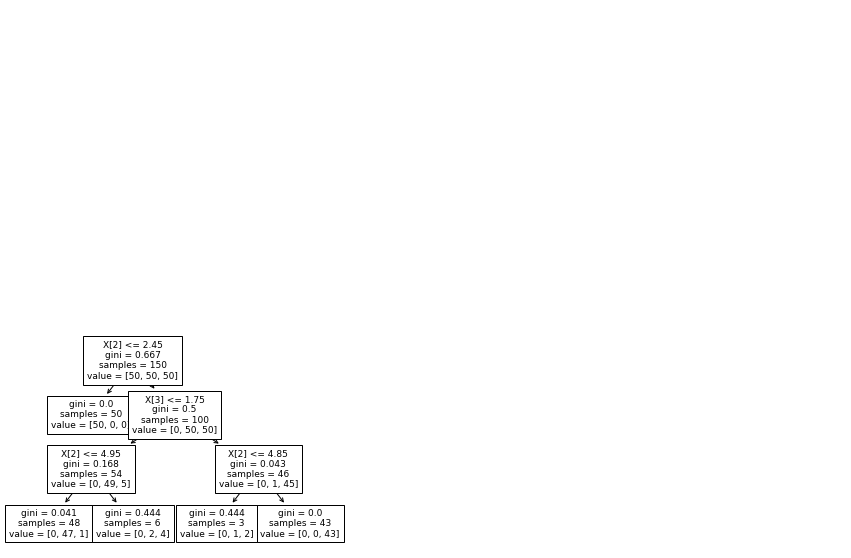

In [11]:
tree.plot_tree(clf,fontsize = 9); # <== if you take off the `;`, you get a lot of output garbage

# This just tries to make it a bit bigger to see 
f = plt.gcf()
f.set_figheight(10)
f.set_figwidth(15)

### Plotting Version 2: 

This version will give you the same info, but prettier and with better control when the tree is big.  However, I had some issues getting it installed on my machine. Make a decent attempt at getting this working, but honestly if it doesn't work, just move on. You can always use version 1. 

[Here's a stackoverflow link that helped me get this working](https://stackoverflow.com/questions/35064304/runtimeerror-make-sure-the-graphviz-executables-are-on-your-systems-path-aft)

In [12]:
import graphviz #<---- You might need to install this one. 
                # See link above for info on getting it on your machine.

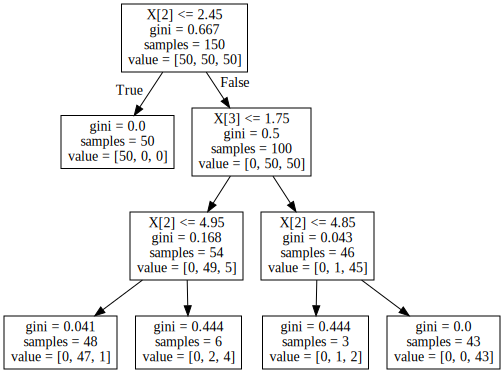

In [13]:
dot_data = tree.export_graphviz(clf, out_file=None) 
graph = graphviz.Source(dot_data) 
# graph.render("iris") 
graph

Below is an even fancier drawing version with extra labels and info. 

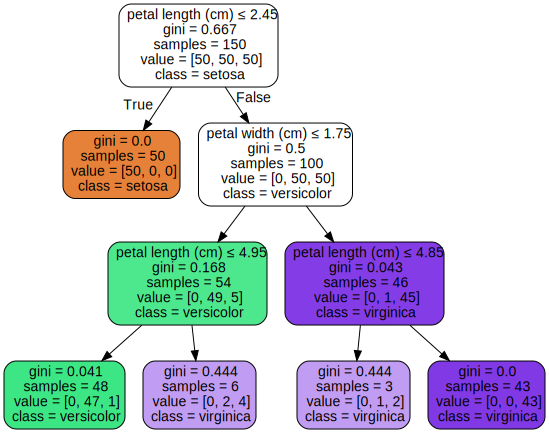

In [14]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                     feature_names=iris.feature_names,  
                     class_names=iris.target_names,  
                     filled=True, rounded=True,  
                     special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

&#9989; **<font color=red>Do this:</font>** Use your decision tree *graphic* to determine the type of Iris predicted by the model for the following input data point. Which leaf node do you end up in? Notice that your predicted answer should be the same as when we did this a few boxes ago. 

| sepal length (cm) | sepal width (cm) | petal length (cm) | petal width (cm) | 
| ----------- | ----------- | ----------- | ----------- |
| 5 | 3 | 1 | 0.2|
| 5 | 1 | 3 | 1|

##ANSWER##

First one lands in the only orange box, right on top. Setosa
Second one is bottom left versicolor box. 

&#9989; **<font color=red>Q:</font>** What does the `max_depth` flag do in the `DecisionTreeClassifier` command?

*Your answer here*

## Visualizing the parameter splits 
Now, if we want to visualize the parameter splits that are being represented with the trees, we can do that.  However, I can't (easily) draw these sorts of figures when I'm using more than two variables. Let's just grab the first two variables and build a classifer off of those. 

In [15]:
X_pair = X[:,:2]
clf_pair = tree.DecisionTreeClassifier().fit(X_pair, iris.target)

&#9989; **<font color=red>Do this:</font>** Use whatever worked for you above to plot your decision tree. 

In [16]:
# Your code here #

In [17]:
##ANSWER## Version 1 plotting
# tree.plot_tree(clf,fontsize=12);

# f = plt.gcf()
# f.set_figheight(10)
# f.set_figwidth(15)

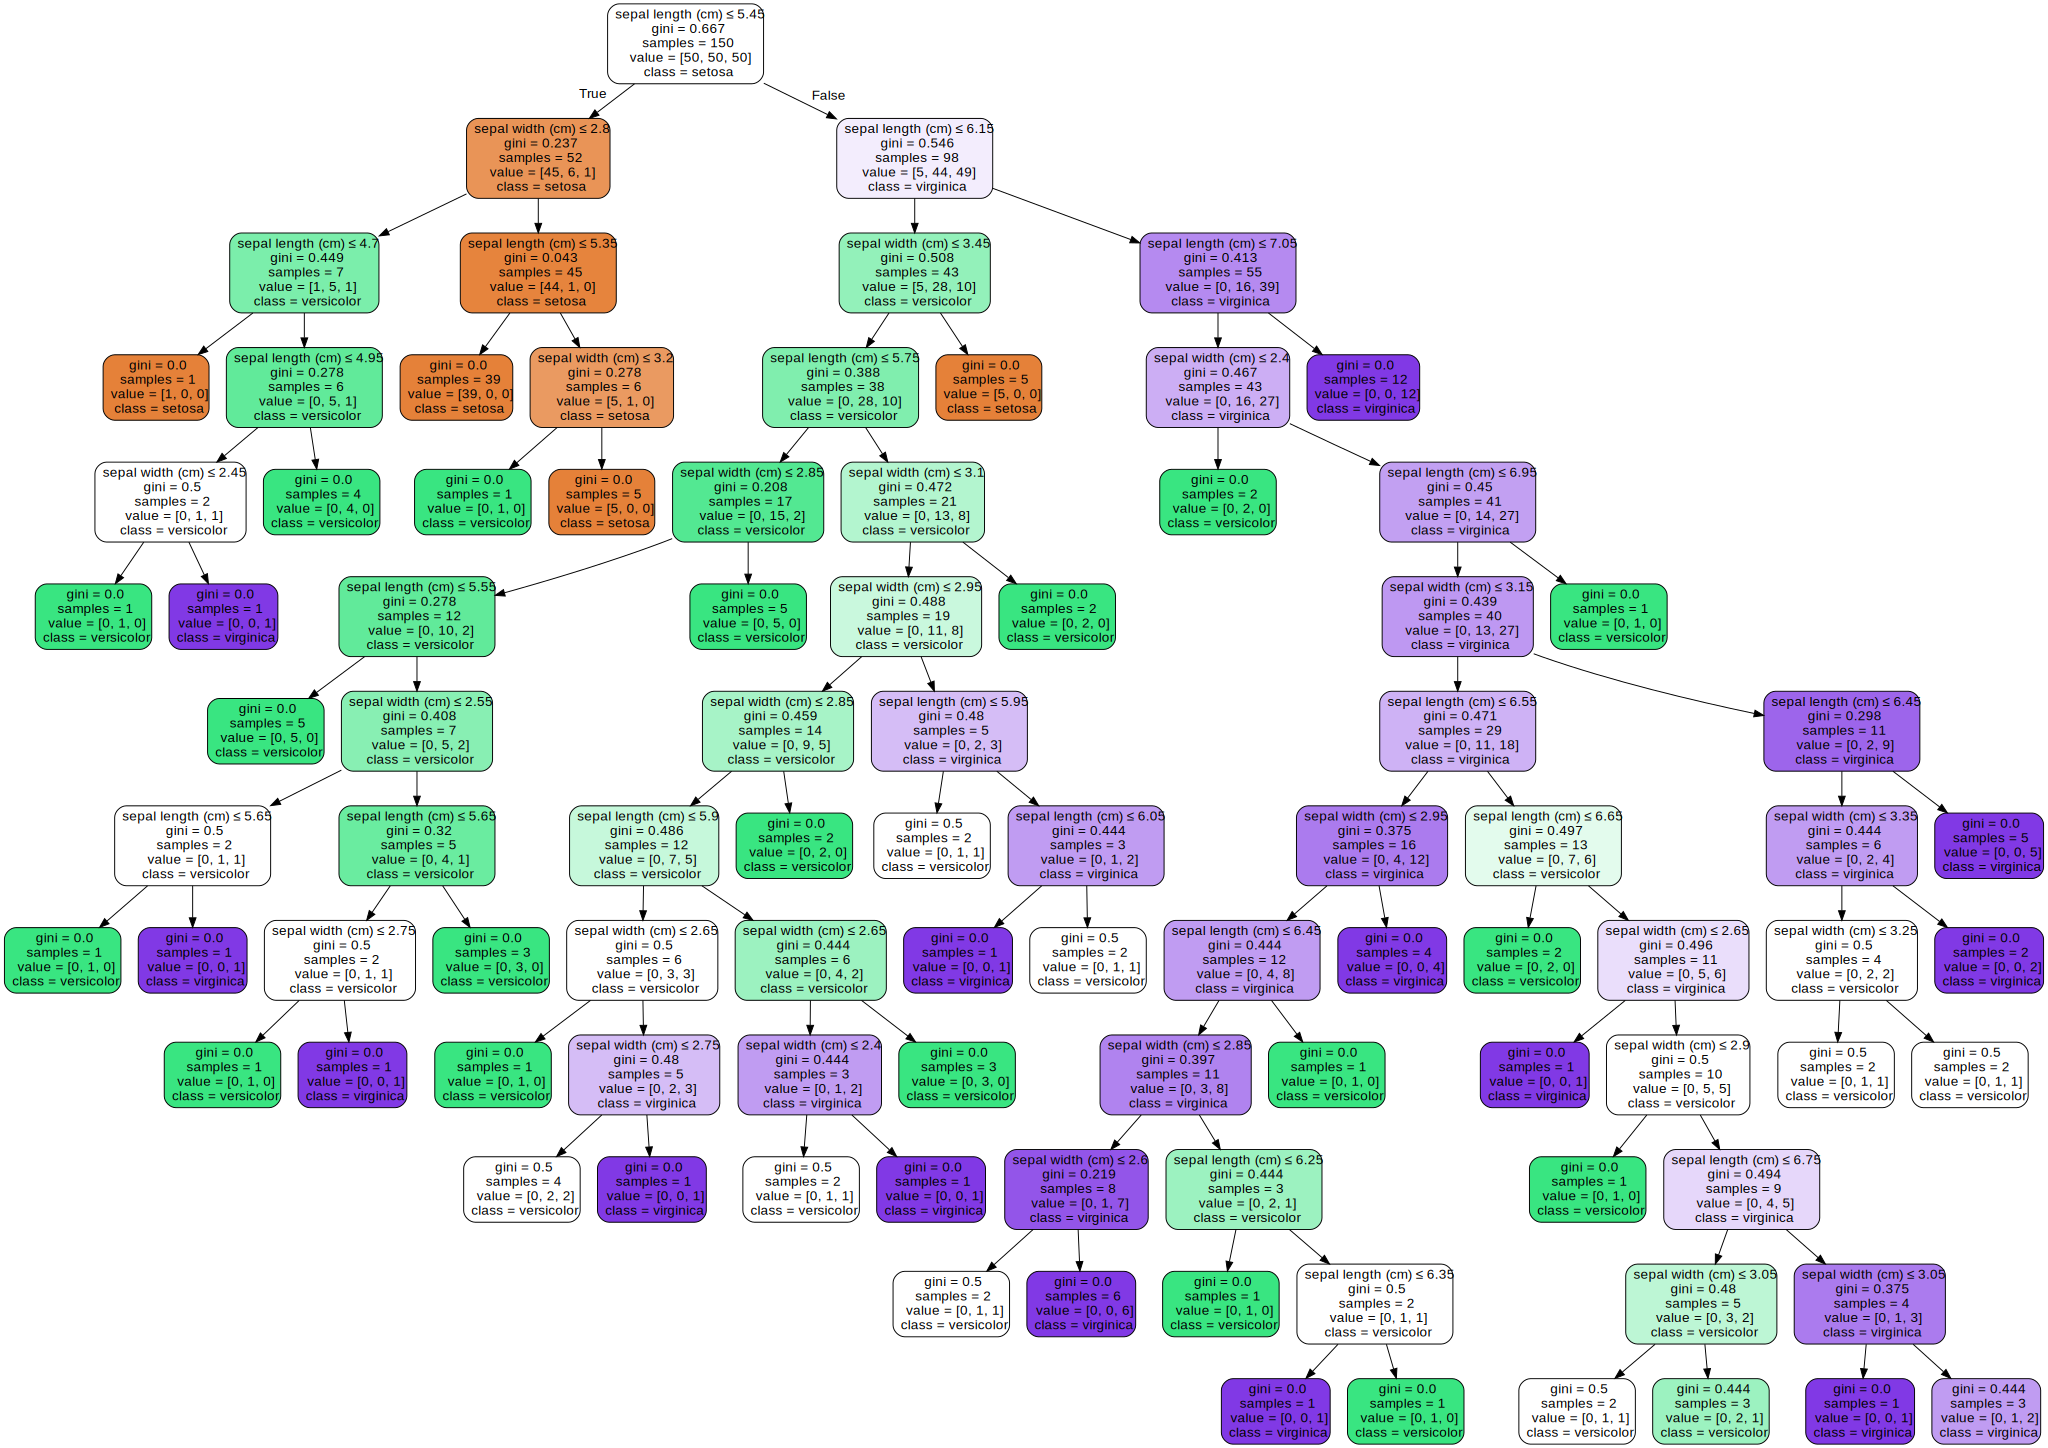

In [18]:
dot_data = tree.export_graphviz(clf_pair, out_file=None, 
                     feature_names=iris.feature_names[:2],  
                     class_names=iris.target_names,  
                     filled=True, rounded=True,  
                     special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

&#9989; **<font color=red>Do this:</font>** Below is some code that will draw the regions of parameter space that get each different prediction.  
- Which labels do the colors red, yellow, and blue match to? 
- What split in the figure does the first split in your tree above correspond to? 
- What changes in this figure if you change the `max_depth` in your tree model?

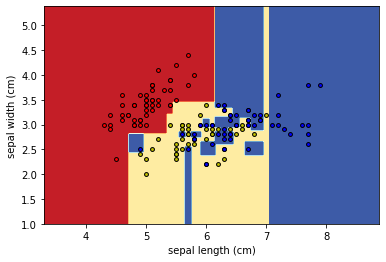

In [19]:
# Bounds for the figure 
x0_min = X[:,0].min()-1
x0_max = X[:,0].max()+1
x1_min = X[:,1].min()-1
x1_max = X[:,1].max()+1

# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02

xx, yy = np.meshgrid(
    np.arange(x0_min, x0_max, plot_step), np.arange(x1_min, x1_max, plot_step)
)
plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

Z = clf_pair.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

# Plot the training points
for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y == i)
    plt.scatter(
        X[idx, 0],
        X[idx, 1],
        c=color,
        label=iris.target_names[i],
        cmap=plt.cm.RdYlBu,
        edgecolor="black",
        s=15,
    )


# Fitting Regression Trees

We can now turn to setting up a basic regression tree.  The framework is quite similar to the classification version. For this example, we're going to use the `Carseat` data where we will predict `Sales` from the rest of the columns. I'll do a bit of cleanup for you so we can get to the good stuff.

In [20]:
carseats = pd.read_csv('Carseats.csv').drop('Unnamed: 0', axis=1)
carseats.ShelveLoc = pd.factorize(carseats.ShelveLoc)[0]
carseats.Urban = carseats.Urban.map({'No':0, 'Yes':1})
carseats.US = carseats.US.map({'No':0, 'Yes':1})
carseats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    int64  
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    int64  
 10  US           400 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 34.5 KB


In [21]:
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,1,65,10,1,1
2,10.06,113,35,10,269,80,2,59,12,1,1
3,7.40,117,100,4,466,97,2,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0


In [22]:
X = carseats.drop(['Sales'], axis = 1)
y = carseats.Sales
X.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,138,73,11,276,120,0,42,17,1,1
1,111,48,16,260,83,1,65,10,1,1
2,113,35,10,269,80,2,59,12,1,1
3,117,100,4,466,97,2,55,14,1,1
4,141,64,3,340,128,0,38,13,1,0


The regression tree function we will use is `DecisionTreeRegressor`. We'll do some basic testing using a train test split 

In [23]:
from sklearn.tree import DecisionTreeRegressor

In [24]:
# Create train/test split 

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 0)

In [25]:
reg_tree = DecisionTreeRegressor(max_depth = 2)
reg_tree.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=2)

&#9989; **<font color=red>Do this:</font>** Draw the resutling tree.  

In [26]:
# Your code here #

In [50]:
##ANSWER##
dot_data = tree.export_graphviz(reg_tree, out_file=None, 
                     feature_names=X.columns,  
                     filled=True, rounded=True,  
                     special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 
# plt.savefig('Tree-CarseatsExample.png')

<Figure size 432x288 with 0 Axes>

&#9989; **<font color=red>Do this:</font>** Use the regression tree you just built to predict the `Sales` value for the test set. What is the resutling MSE?

In [28]:
# Your code here #

In [29]:
##ANSWER##

y_predict = reg_tree.predict(X_test)
mean_squared_error(y_predict,y_test)

4.1428726824987825

# Bagging 

Alrighty, so now we can create a single tree to do our classification or regression, but we'd like to be able to use ensemble models to create a pile of trees to give a more robust predction. 

Let's try doing this the hard way first. We're going to set up the bagging on our `carseats` data. We'll use $B=3$ to create our bagged model. So, step one is to generate three bootstrap samples, meaning I generate data sets by sampling $n=400$ points with replacement. 

In [30]:
X1 = carseats.sample(n = 400, replace = True, random_state = 42)
y1 = X1.Sales
X1 = X1.drop(['Sales'], axis = 1)

X2 = carseats.sample(n = 400, replace = True, random_state = 43)
y2 = X2.Sales
X2 = X2.drop(['Sales'], axis = 1)

X3 = carseats.sample(n = 400, replace = True, random_state = 44)
y3 = X3.Sales
X3 = X3.drop(['Sales'], axis = 1)


&#9989; **<font color=red>Do this:</font>** Fit three regression trees of depth 2, called `reg_tree1`, `reg_tree2`, and `reg_tree3` on the three samples just generated. How similar are the tree structures?

In [31]:
# Your code here #

In [32]:
##ANSWER##
reg_tree1 = DecisionTreeRegressor(max_depth = 2)
reg_tree1.fit(X1,y1)

reg_tree2 = DecisionTreeRegressor(max_depth = 2)
reg_tree2.fit(X2,y2)

reg_tree3 = DecisionTreeRegressor(max_depth = 2)
reg_tree3.fit(X3,y3)

DecisionTreeRegressor(max_depth=2)

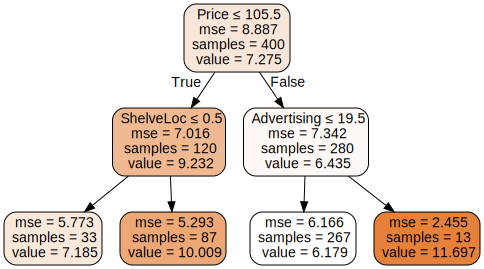

In [33]:
##ANSWER##
dot_data = tree.export_graphviz(reg_tree1, out_file=None, 
                     feature_names=X1.columns,  
                     filled=True, rounded=True,  
                     special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

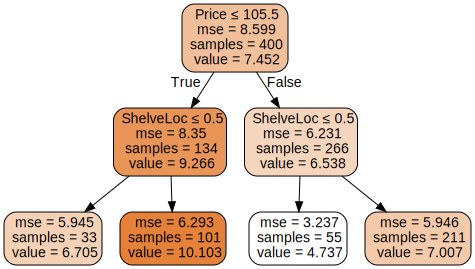

In [34]:
##ANSWER##
dot_data = tree.export_graphviz(reg_tree2, out_file=None, 
                     feature_names=X2.columns,  
                     filled=True, rounded=True,  
                     special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

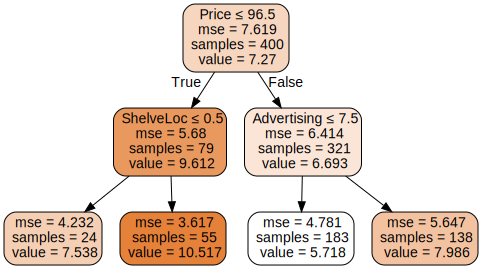

In [35]:
##ANSWER##
dot_data = tree.export_graphviz(reg_tree3, out_file=None, 
                     feature_names=X3.columns,  
                     filled=True, rounded=True,  
                     special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

&#9989; **<font color=red>Do this:</font>** Predict the `Sales` value for the first data point in the carseats data set (`datapoint` below) using each of the three trees just generated. For the purposes of this exercise, don't worry about whether that data point was used to build the tree or not. What is the average value of the three numbers? This is the bagged prediction for this input data. 

In [36]:
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,1,65,10,1,1
2,10.06,113,35,10,269,80,2,59,12,1,1
3,7.40,117,100,4,466,97,2,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0


In [37]:
datapoint = np.array(carseats.iloc[0,1:]).reshape(1,-1)
datapoint

array([[138.,  73.,  11., 276., 120.,   0.,  42.,  17.,   1.,   1.]])

In [38]:
# Your code to get the bagged prediction for `datapoint` here.

In [39]:
##ANSWER##
v1, v2, v3 = reg_tree1.predict(datapoint), reg_tree2.predict(datapoint), reg_tree3.predict(datapoint)

print(v1, v2, v3)
print(np.average((v1, v2, v3)))



[6.17925094] [4.73727273] [7.98637681]
6.300966825065507


Did you really need to do all that? Well, no actually, but this goes under the "eating your vegetables exactly once" part of the lab. Of course, `sklearn` has built in functions to do bagging for us. In reality, it just has a random forest function, but if we really want to do bagging, we can cheat. 

Remember, for random forests, we essentially do bagging but we only allow for a subset of $m \leq p$ variables to be considered at each splitting step. So if we want bagging, we set the `max_features` to be the total number of features.

In [40]:
from sklearn.ensemble import RandomForestRegressor

In [41]:
bagged_carseats = RandomForestRegressor(max_features = 10 )
bagged_carseats.fit(X,y)


RandomForestRegressor(max_features=10)

&#9989; **<font color=red>Do this:</font>** Build a random forest model instead where the maximum number of features used at each step is $m = \sqrt {p}$. 

In [42]:
# Your code here #

In [43]:
##ANSWER##
forest_carseats = RandomForestRegressor(max_features = 'sqrt' , 
                                        oob_score = True)
forest_carseats.fit(X,y)


RandomForestRegressor(max_features='sqrt', oob_score=True)

&#9989; **<font color=red>Do this:</font>** The `RandomForest` command actually can do our out-of-bag test error for us.  Determine the OOB error on the forsest model you built just above. 

*Hint:* You need to include `oob_score = True` when you initialize the model, then the OOB score is a parameter of the class.  See [the documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) for further details. 

In [44]:
##ANSWER##
forest_carseats.oob_score_

0.6394256581105167

&#9989; **<font color=red>Do this:</font>** How does the number of trees used (`n_estimators` in this code) affect the error? Generate a plot like Fig 8.10 in the book for our `carseats` data. How many trees should we use? 

In [45]:
# Your code here #

In [46]:
##ANSWER##

# Liz says..... there's something wrong with this code but students in class were getting the right figure. 
# See screenshots in the folder and update for next year.

Bs = np.linspace(1,500, 100)
Bs = np.round(Bs,0)
Bs

errors = []

for B in Bs:
    forest_carseats = RandomForestRegressor(max_features = 0.5 , 
                                            max_depth = 2,
                                        oob_score = True)
    forest_carseats.fit(X_train,y_train)
    errors.append(mean_squared_error(forest_carseats.predict(X_test),y_test))

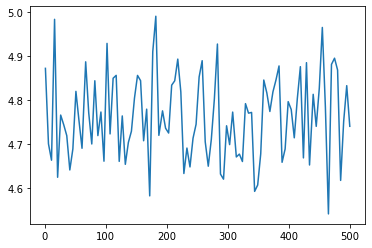

In [47]:
##ANSWER##
# Arg, not a lot of structure here.  Seems like more trees doesn't do much, all the same noise

plt.plot(Bs, errors)

# Lab Survey

To get credit for today's lab, fill out the following survey before the end of class:

https://forms.gle/hX8GT5FJ2fNMeTo1A

Note this is the same link for every lab, so you will fill this out multiple times this semester.



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [48]:
##ANSWER## 
# This cell gets the name of the current notebook. Needs a sec
# to run before it works

from jupyterinstruct import InstructorNotebook
this_notebook = InstructorNotebook.getname()


##ANSWER## 

ModuleNotFoundError: No module named 'jupyterinstruct'

In [ ]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

studentnotebook = InstructorNotebook.makestudent(this_notebook)
InstructorNotebook.validate(studentnotebook)